# Solution of NX-465 Mini-project MP1
## Visual Surround Suppression using Excitation-Inhibition Circuits
**Spring semester 2026**

*Team members: Kamegne Yann Eddy Sipofo & Arthur Stefano Moscheni*


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from tqdm.auto import tqdm

# ── Global neuron parameters ──────────────────────────────────────────────────
theta    = 20.0   # mV  — firing threshold
u_reset  = -10.0  # mV  — reset potential
R        = 1.0    # MOhm
dt       = 0.5    # ms  — integration time step
tau_m    = 20.0   # ms  — membrane time constant
n_bg     = 25.0   # mean Poisson background events per time step

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize']  = 14
plt.rcParams['axes.labelsize']  = 12


---
## Exercise 0 — Getting Started: Population of LIF neurons

This project uses **Leaky Integrate-and-Fire (LIF)** neurons. The membrane potential of neuron
$i$ evolves as:

$$\tau_m \frac{du_i(t)}{dt} = -u_i(t) + R\,I_i(t)$$

When $u_i$ crosses threshold $\theta$, it emits a spike and is reset to $u_{reset}$.

**Neuron parameters:** $\theta=20$ mV, $u_{reset}=-10$ mV, $R=1\,\text{M}\Omega$,
$\Delta t=0.5$ ms, $\tau_m=20$ ms.

---

**0.1.** Simulate the dynamics of $N=100$ unconnected neurons for $T=1000$ ms, receiving
the slowly oscillating input $I_i(t)=I_0(1+\sin(\omega t))$ with $I_0=20$ nA,
$\omega=10$ rad/s. Initialise all neurons uniformly: $u_i(0)\sim\mathrm{Unif}(u_{reset},\theta)$.

- Make a **rasterplot** of the spiking times of all neurons over time.
- Plot the **mean firing rate** over time and compare it to the external input.


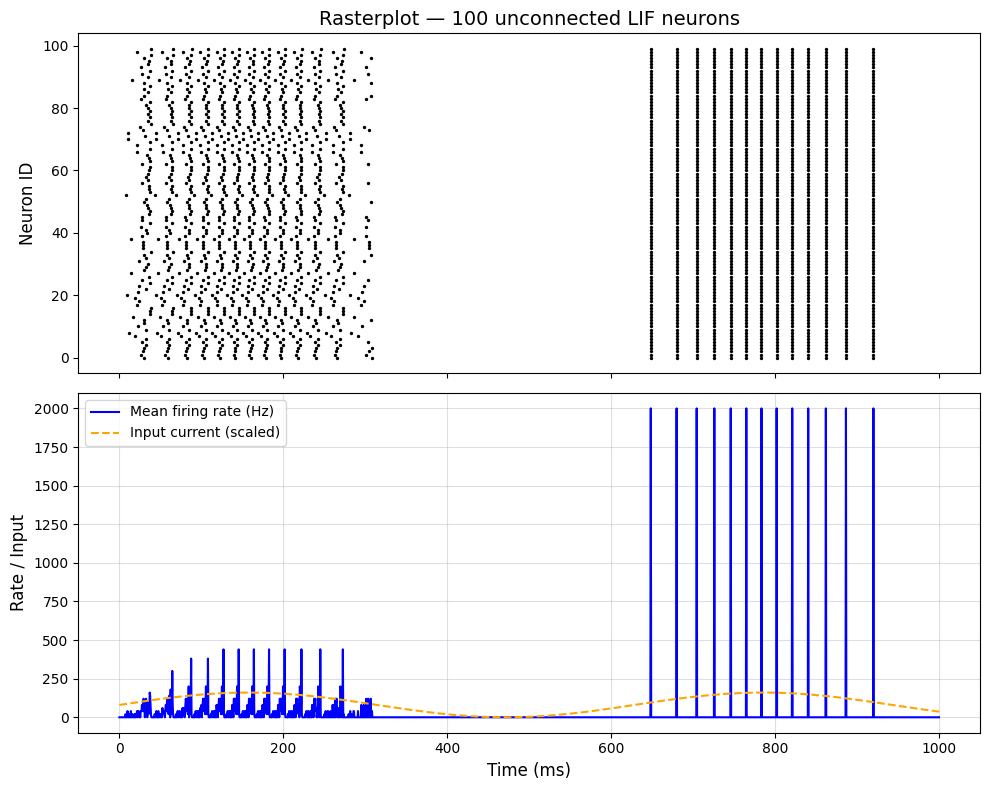

In [2]:
# ── Exercise 0.1 ─────────────────────────────────────────────────────────────

def simulate_unconnected_lif(N=100, T=1000.0, I0=20.0, omega=10.0, seed=0):
    """Simulate N unconnected LIF neurons with oscillatory input."""
    np.random.seed(seed)
    n_steps = int(T / dt)
    time    = np.arange(n_steps) * dt
    u       = np.random.uniform(u_reset, theta, N)

    spike_times   = []
    spike_neurons = []
    rate_hist     = np.zeros(n_steps)
    I_hist        = np.zeros(n_steps)

    for step in range(n_steps):
        t = time[step]
        # omega in rad/s, t in ms → convert time to seconds
        I = I0 * (1.0 + np.sin(omega * t * 1e-3))
        I_hist[step] = I

        u_new  = u + dt * (-u + R * I) / tau_m
        spikes = u_new >= theta
        u_new[spikes] = u_reset
        u = u_new

        idx = np.where(spikes)[0]
        spike_times.extend([t] * len(idx))
        spike_neurons.extend(idx)
        rate_hist[step] = len(idx) / N / (dt * 1e-3)   # Hz

    return time, spike_times, spike_neurons, rate_hist, I_hist


time_01, spk_t, spk_n, rate_01, I_01 = simulate_unconnected_lif()

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 8))
ax1.scatter(spk_t, spk_n, s=2, color='black')
ax1.set_ylabel('Neuron ID')
ax1.set_title('Rasterplot — 100 unconnected LIF neurons')

ax2.plot(time_01, rate_01,            label='Mean firing rate (Hz)', color='blue')
ax2.plot(time_01, I_01 * 4, linestyle='--', label='Input current (scaled)',  color='orange')
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Rate / Input')
ax2.legend()
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


**Observation:** Because all neurons receive the *identical* deterministic input and are reset
to the same potential after spiking, the network fires synchronously. The mean firing rate
tracks the positive half of the oscillatory input: spikes occur in bursts near each peak of
$I(t)$, with silence in between. There is no noise to desynchronise the neurons.


**0.2.** We now add stochastic background input to each neuron, modelling a Poisson-distributed
baseline arrival of spikes from outside the population:

$$I_i^{bg}(t_k) \sim 1\,\text{nA}\cdot\mathrm{Poisson}(\bar{n}_{bg}), \quad \bar{n}_{bg}=25$$

The total input is $I_i(t) = I_i^{ext}(t) + I_i^{bg}(t)$.

Plot the **f-I curve** for $N=100$ neurons with background noise:
- Take $I_0=-10$ to $50$ nA in steps of $5$ nA; for each simulate $T=100$ ms and report the
  mean rate averaged over the last 50 ms.
- On the same plot, show the **theoretical f-I curve** (no noise, derived in class).


f-I curve:   0%|          | 0/13 [00:00<?, ?it/s]

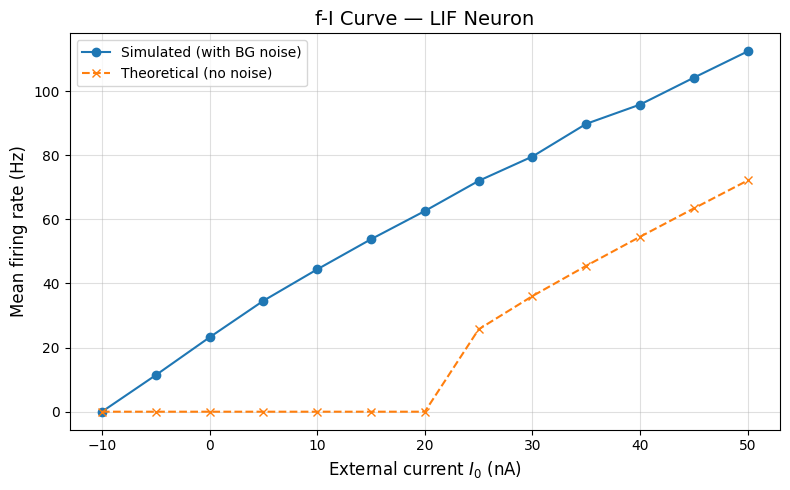

In [3]:
# ── Exercise 0.2 ─────────────────────────────────────────────────────────────

def simulate_lif_bg(I0_const, N=100, T=100.0):
    """Single f-I point: constant external current + Poisson background noise."""
    n_steps = int(T / dt)
    u = np.random.uniform(u_reset, theta, N)
    rate_hist = np.zeros(n_steps)

    for step in range(n_steps):
        I = I0_const + 1.0 * np.random.poisson(n_bg, N)
        u_new  = u + dt * (-u + R * I) / tau_m
        spikes = u_new >= theta
        u_new[spikes] = u_reset
        u = u_new
        rate_hist[step] = np.sum(spikes) / N / (dt * 1e-3)

    return rate_hist


def theoretical_fi(I_vals):
    """Analytical f-I curve for the LIF neuron (no noise, no refractory period)."""
    rates = np.zeros_like(I_vals, dtype=float)
    for i, I in enumerate(I_vals):
        if R * I > theta:
            rates[i] = 1.0 / (tau_m * 1e-3 * np.log((R * I - u_reset) / (R * I - theta)))
    return rates


I0_vals  = np.arange(-10, 55, 5, dtype=float)
last_50  = int(50.0 / dt)
sim_rates = []

np.random.seed(42)
for I0 in tqdm(I0_vals, desc="f-I curve"):
    r = simulate_lif_bg(I0)
    sim_rates.append(np.mean(r[-last_50:]))

theo_rates = theoretical_fi(I0_vals)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(I0_vals, sim_rates,  'o-',  label='Simulated (with BG noise)')
ax.plot(I0_vals, theo_rates, 'x--', label='Theoretical (no noise)')
ax.set_xlabel('External current $I_0$ (nA)')
ax.set_ylabel('Mean firing rate (Hz)')
ax.set_title('f-I Curve — LIF Neuron')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


**Differences:** The theoretical curve has a hard threshold — no firing below $I_{min}=\theta/R=20$ nA.
With Poisson background noise, neurons can fire even below this threshold because noise fluctuations
occasionally push the membrane above $\theta$. This *smooths* the curve around threshold and
shifts its onset to lower currents, a hallmark of noise-driven excitability.


---
## Exercise 1 — Excitation-Inhibition Balance

We now group neurons into two populations (E and I) with synaptic interactions:

$$I_i(t) = \underbrace{\sum_{j=1}^{N} w_{ij}\,s_j(t-\tau_{delay})}_{I_i^{syn}(t)}
           + I_i^{ext}(t) + I_i^{bg}(t)$$

where $w_{ij}$ is the synaptic strength (pC) and $\tau_{delay}$ is the transmission delay.
Excitatory-to-any weight: $w_{E\leftarrow E} = w_{I\leftarrow E} = J$.
Inhibitory-to-any weight: $w_{E\leftarrow I} = w_{I\leftarrow I} = -gJ$.

The network is sparsely connected: each neuron receives exactly $K_E = pN_E$ excitatory
and $K_I = pN_I$ inhibitory connections.

**Network parameters:** $N_E=1000$, $\gamma=0.25$, $p=0.02$, $g=5$, $J=45$ pC,
$\tau_{delay}=2$ ms.

---

**1.1.** Write a function `generate_sparse_connectivity(NE, NI, KE, KI, J, g)`
that generates the random sparse weight matrix using `scipy.sparse.csr_matrix`.


In [4]:
# ── Exercise 1.1 ─────────────────────────────────────────────────────────────

def generate_sparse_connectivity(NE, NI, KE, KI, J, g):
    """
    Random sparse E/I connectivity matrix of shape (NE+NI) x (NE+NI).
    Each post-synaptic neuron receives exactly KE excitatory (weight +J)
    and KI inhibitory (weight -gJ) connections.
    """
    N = NE + NI
    row_ind, col_ind, data = [], [], []

    for i in range(N):
        exc_src = np.random.choice(NE,             KE, replace=False)
        inh_src = np.random.choice(np.arange(NE, N), KI, replace=False)

        row_ind.extend([i] * (KE + KI))
        col_ind.extend(exc_src)
        col_ind.extend(inh_src)
        data.extend([J]    * KE)
        data.extend([-g*J] * KI)

    return csr_matrix((data, (row_ind, col_ind)), shape=(N, N))


**1.2.** Implement the recurrent network. Plot the **f-I curves** for the E and I populations
in the same figure. Convince yourself that the network is in the **balanced state**
($r_E \approx r_I$ across inputs).


Balanced network f-I:   0%|          | 0/13 [00:00<?, ?it/s]

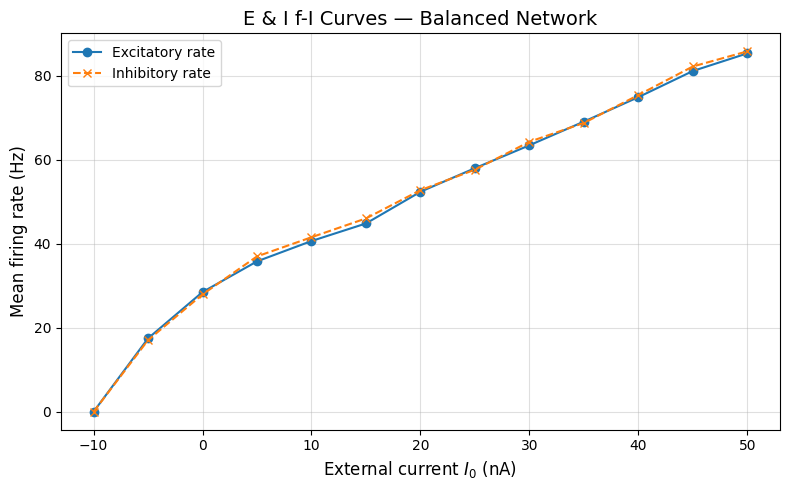

In [5]:
# ── Exercise 1.2 ─────────────────────────────────────────────────────────────

NE        = 1000
gamma     = 0.25
NI        = int(gamma * NE)
N_tot     = NE + NI
p         = 0.02
KE        = int(p * NE)
KI        = int(p * NI)
g_val     = 5.0
J_val     = 45.0   # pC
delay_ms  = 2.0    # ms
delay_steps = int(delay_ms / dt)


def simulate_network(w, I_ext, T, bg_noise=True):
    """
    Simulate the recurrent E/I network.
    I_ext : (N, n_steps) array of external currents — must be float dtype.
    Returns time, spike_hist (N x n_steps bool), rate_E, rate_I arrays.
    """
    N       = w.shape[0]
    n_steps = int(T / dt)
    time    = np.arange(n_steps) * dt

    u          = np.random.uniform(u_reset, theta, N)
    spk_hist   = np.zeros((N, n_steps), dtype=bool)
    rate_E_arr = np.zeros(n_steps)
    rate_I_arr = np.zeros(n_steps)

    for step in range(n_steps):
        # External + background
        I = I_ext[:, step].copy().astype(float)
        if bg_noise:
            I += 1.0 * np.random.poisson(n_bg, N)

        # Synaptic input with delay (sparse matrix–vector product)
        if step >= delay_steps:
            past = spk_hist[:, step - delay_steps].astype(float)
            I_syn = w.dot(past) / dt        # divide by dt to get amplitude in nA
        else:
            I_syn = np.zeros(N)

        u_new  = u + dt * (-u + R * (I + I_syn)) / tau_m
        spikes = u_new >= theta
        u_new[spikes] = u_reset
        u = u_new

        spk_hist[:, step] = spikes
        rate_E_arr[step]  = np.sum(spikes[:NE]) / NE / (dt * 1e-3)
        rate_I_arr[step]  = np.sum(spikes[NE:]) / NI / (dt * 1e-3)

    return time, spk_hist, rate_E_arr, rate_I_arr


np.random.seed(0)
w_net = generate_sparse_connectivity(NE, NI, KE, KI, J_val, g_val)

I0_net = np.arange(-10, 55, 5, dtype=float)
E_rates, I_rates = [], []

for I0 in tqdm(I0_net, desc="Balanced network f-I"):
    I_ext_fi = np.full((N_tot, int(100.0 / dt)), I0)
    _, _, rE, rI = simulate_network(w_net, I_ext_fi, 100.0)
    E_rates.append(np.mean(rE[-int(50.0 / dt):]))
    I_rates.append(np.mean(rI[-int(50.0 / dt):]))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(I0_net, E_rates, 'o-',  label='Excitatory rate')
ax.plot(I0_net, I_rates, 'x--', label='Inhibitory rate')
ax.set_xlabel('External current $I_0$ (nA)')
ax.set_ylabel('Mean firing rate (Hz)')
ax.set_title('E & I f-I Curves — Balanced Network')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


The curves for E and I nearly overlap across all input levels, confirming that the network
operates in the **balanced state** ($r_E \approx r_I$).


**1.3.** Show that the expected synaptic input to any neuron is
$\langle I^{syn}(t)\rangle = J K_E(r_E(t) - g\gamma\, r_I(t))$.

**Derivation:**
Split the synaptic sum into E and I contributions. Each neuron receives $K_E$ excitatory
connections of weight $J$ and $K_I$ inhibitory connections of weight $-gJ$:

$$\langle I^{syn}_i(t)\rangle = J K_E\,r_E(t) - gJ K_I\, r_I(t)$$

Since $N_I = \gamma N_E$ and $K_A = pN_A$, we have $K_I = \gamma K_E$. Substituting:

$$\boxed{\langle I^{syn}_i(t)\rangle = J K_E\bigl(r_E(t) - g\gamma\, r_I(t)\bigr)}$$


**1.4.** Using the formula above, argue what value of $g$ is needed for the network to be
**inhibition-dominated** (inhibitory contribution $> $ excitatory contribution).
Report (via simulation) what happens when the condition is violated.


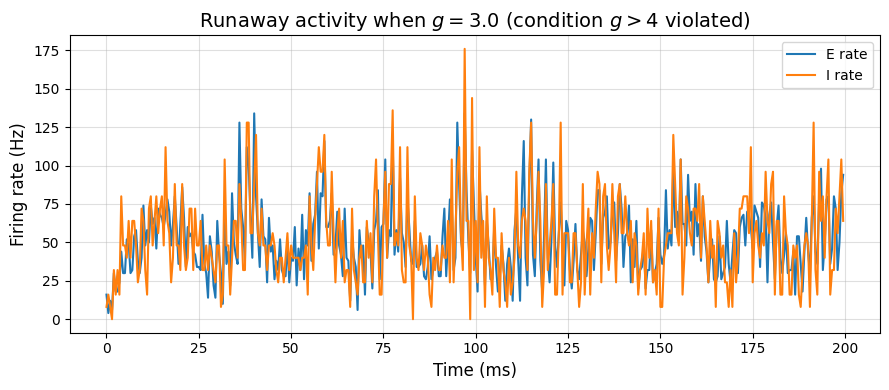

In [6]:
# ── Exercise 1.4 ─────────────────────────────────────────────────────────────
# Condition for inhibition dominance: gγ r_I > r_E.
# In the balanced state r_E ≈ r_I, so gγ > 1 → g > 1/γ = 4.
# With γ=0.25: g must be STRICTLY > 4.

# Simulate with g=3.0 (condition violated)
np.random.seed(1)
w_unst = generate_sparse_connectivity(NE, NI, KE, KI, J_val, g=3.0)
I_un   = np.zeros((N_tot, int(200.0 / dt)))
_, _, rE_un, rI_un = simulate_network(w_unst, I_un, 200.0)

time_un = np.arange(len(rE_un)) * dt
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(time_un, rE_un, label='E rate')
ax.plot(time_un, rI_un, label='I rate')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Firing rate (Hz)')
ax.set_title('Runaway activity when $g=3.0$ (condition $g>4$ violated)')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


**Answer (1.4):** For inhibition dominance we need $g\gamma > 1$, i.e. $g > 1/\gamma = 4$.

When $g < 4$ (e.g. $g=3$), excitation wins over inhibition. Activity grows in a positive
feedback loop and the firing rates **run away to saturation**, as seen in the plot above.
With the default $g=5 > 4$, inhibition clamps the network into the balanced low-rate regime.


**1.5.** Simulate the network for $T=1000$ ms with the following time-varying input
($I_0=10$ mV, $\omega=25$ rad/s):

$$I_i^{ext,E}(t) = \begin{cases}I_0(1+\sin\omega t) & 0\le t < 500\,\text{ms}\\0 & \text{otherwise}\end{cases}$$
$$I_i^{ext,I}(t) = \begin{cases}0 & 0\le t < 500\,\text{ms}\\I_0(1+\sin\omega t) & \text{otherwise}\end{cases}$$

Produce:
- A **rasterplot** (100 E neurons in blue, 25 I neurons in red).
- A **population rate plot** with 20 ms bins.


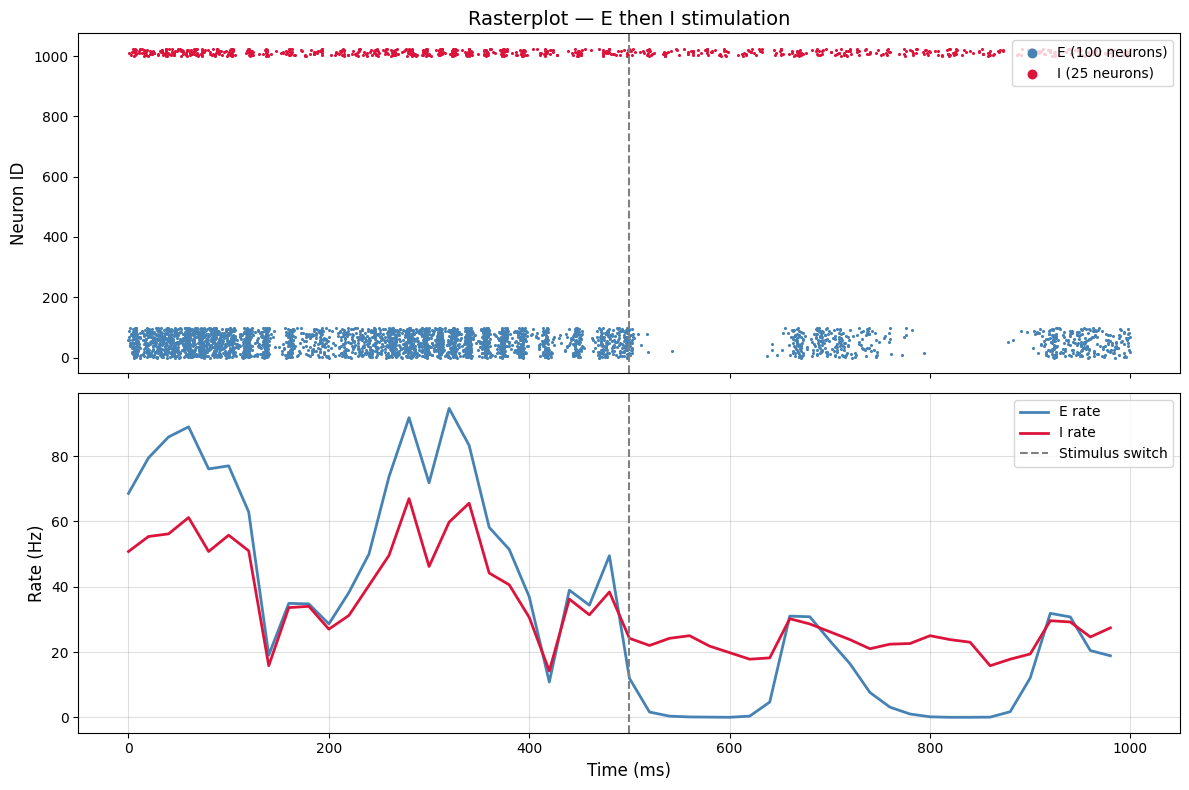

In [7]:
# ── Exercise 1.5 ─────────────────────────────────────────────────────────────

T15     = 1000.0
omega15 = 25.0        # rad/s
I0_15   = 10.0        # nA
n15     = int(T15 / dt)
time_15 = np.arange(n15) * dt

I_ext_15 = np.zeros((N_tot, n15))
mask_E = time_15 <  500
mask_I = time_15 >= 500
I_ext_15[:NE, mask_E] = I0_15 * (1 + np.sin(omega15 * time_15[mask_E] * 1e-3))
I_ext_15[NE:, mask_I] = I0_15 * (1 + np.sin(omega15 * time_15[mask_I] * 1e-3))

np.random.seed(2)
_, spk_hist_15, rE_15, rI_15 = simulate_network(w_net, I_ext_15, T15)

# Collect spikes for raster (100 E, 25 I)
spk_t_e, spk_n_e = [], []
spk_t_i, spk_n_i = [], []
for nid in range(100):
    t_spk = time_15[spk_hist_15[nid, :]]
    spk_t_e.extend(t_spk); spk_n_e.extend([nid] * len(t_spk))
for nid in range(NE, NE + 25):
    t_spk = time_15[spk_hist_15[nid, :]]
    spk_t_i.extend(t_spk); spk_n_i.extend([nid] * len(t_spk))

# 20 ms bins → 40 steps
bin_w   = 40
rE_bin  = rE_15.reshape(-1, bin_w).mean(axis=1)
rI_bin  = rI_15.reshape(-1, bin_w).mean(axis=1)
t_bins  = np.arange(len(rE_bin)) * dt * bin_w

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.scatter(spk_t_e, spk_n_e, s=1.5, color='steelblue', label='E (100 neurons)')
ax1.scatter(spk_t_i, spk_n_i, s=1.5, color='crimson',   label='I (25 neurons)')
ax1.axvline(500, color='gray', lw=1.5, linestyle='--')
ax1.set_ylabel('Neuron ID')
ax1.set_title('Rasterplot — E then I stimulation')
ax1.legend(loc='upper right', markerscale=5)

ax2.plot(t_bins, rE_bin, color='steelblue', lw=2, label='E rate')
ax2.plot(t_bins, rI_bin, color='crimson',   lw=2, label='I rate')
ax2.axvline(500, color='gray', lw=1.5, linestyle='--', label='Stimulus switch')
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Rate (Hz)')
ax2.legend()
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


**1.6. Discussion**

**Why stimulating a single population breaks the balance:**
From Ex 1.3, balanced state requires $r_E \approx r_I$. When only E receives input, E rates
increase, but I rates lag because I only sees balanced recurrent input plus the extra E-drive
which arrives with a delay and is shared. The asymmetry breaks the cancellation
$r_E - g\gamma r_I \approx 0$, driving both populations away from their shared fixed point.

**Why stimulating I can *decrease* its own firing rate (paradoxical response):**
In the inhibition-dominated regime ($g\gamma > 1$), the I population depends critically on
recurrent excitatory drive from E to sustain its own activity. When extra current is injected
into I, I spikes more, strongly suppressing E neurons. The loss of excitation from E is so large
that it overwhelms the injected current, ultimately reducing I's own firing — a hallmark of
**Inhibition-Stabilised Networks (ISN)**.


---
## Exercise 2 — Field Model of the Cortical Sheet

We now use each E/I unit of Exercise 1 as a building block and couple $N_{units}$ of them
on a ring. The unit-unit connectivity matrix $W$ of size $2N_{units}\times 2N_{units}$
encodes Mexican-hat lateral interactions between units:

$$W^{E\leftarrow E}_{\alpha\beta} = W_0\,f(x_\alpha, x_\beta), \quad
  W^{I\leftarrow E}_{\alpha\beta} = g\gamma W_0\,(1-f(x_\alpha,x_\beta)), \quad
  W^{E\leftarrow I} = W^{I\leftarrow I} = 0$$

where $f=1$ if the periodic distance $d(x_\alpha,x_\beta)\le\sigma$, 0 otherwise,
and self-connections are excluded ($\alpha\ne\beta$).

**2.1.** Write down the equations for the external input to unit $\alpha$ from all other units.


**Answer (2.1):**

$$I^{ext,E}_{\alpha}(t) = \sum_{\beta\ne\alpha} W^{E\leftarrow E}_{\alpha\beta}\;r_E^\beta(t-\tau_{delay})$$

$$I^{ext,I}_{\alpha}(t) = \sum_{\beta\ne\alpha} W^{I\leftarrow E}_{\alpha\beta}\;r_E^\beta(t-\tau_{delay})$$

Only excitatory populations project between units; there are no cross-unit $I\to E$ or
$I\to I$ connections.


**2.2.** Implement the cortical sheet model and verify that, with unit-unit interactions
disabled ($W_0=0$), each E-I unit is still in the balanced state.

*Hint:* wrap the single E-I unit code in a class with a `step(I_E, I_I)` method.


In [8]:
# ── Exercise 2.2 & 2.3 — EIUnit class & unit connectivity ────────────────────

class EIUnit:
    """Single E-I unit wrapping the LIF network with a ring delay buffer."""

    def __init__(self, w_local, buffer_size=500):
        self.w          = w_local
        self.u          = np.random.uniform(u_reset, theta, N_tot)
        # Circular spike buffer (avoids storing the entire history)
        self.spk_buf    = np.zeros((N_tot, buffer_size), dtype=bool)
        self.buf_size   = buffer_size
        self.step_idx   = 0

    def step(self, I_E_ext, I_I_ext):
        """Advance one time step; return (r_E, r_I) in Hz."""
        I = np.zeros(N_tot)
        I[:NE] = I_E_ext
        I[NE:] = I_I_ext
        I     += 1.0 * np.random.poisson(n_bg, N_tot)    # background noise

        if self.step_idx >= delay_steps:
            past_col = (self.step_idx - delay_steps) % self.buf_size
            I_syn    = self.w.dot(self.spk_buf[:, past_col].astype(float)) / dt
        else:
            I_syn = np.zeros(N_tot)

        u_new  = self.u + dt * (-self.u + R * (I + I_syn)) / tau_m
        spikes = u_new >= theta
        u_new[spikes] = u_reset
        self.u = u_new

        self.spk_buf[:, self.step_idx % self.buf_size] = spikes
        self.step_idx += 1

        rE = np.sum(spikes[:NE]) / NE / (dt * 1e-3)
        rI = np.sum(spikes[NE:]) / NI / (dt * 1e-3)
        return rE, rI


def generate_unit_connectivity(Nunits, sigma, W0, g, gamma):
    """
    Returns W_EE and W_IE matrices of shape (Nunits, Nunits).
    Periodic ring distance: positions equally spaced on [0,1).
    """
    W_EE = np.zeros((Nunits, Nunits))
    W_IE = np.zeros((Nunits, Nunits))
    pos  = np.linspace(0, 1, Nunits, endpoint=False)

    for a in range(Nunits):
        for b in range(Nunits):
            if a == b:
                continue
            d    = abs(pos[a] - pos[b])
            dist = min(d, 1.0 - d)        # periodic distance
            f    = 1.0 if dist <= sigma else 0.0
            W_EE[a, b] = W0 * f
            W_IE[a, b] = g * gamma * W0 * (1 - f)

    return W_EE, W_IE


**2.4.** Simulate $N_{units}=10$ E-I units on a ring for $T=200$ ms with $W_0=90$ pC,
$\sigma=0.2$. Produce a 2D heatmap of excitatory population activity over time.
Describe the bump formation and explain its stability.


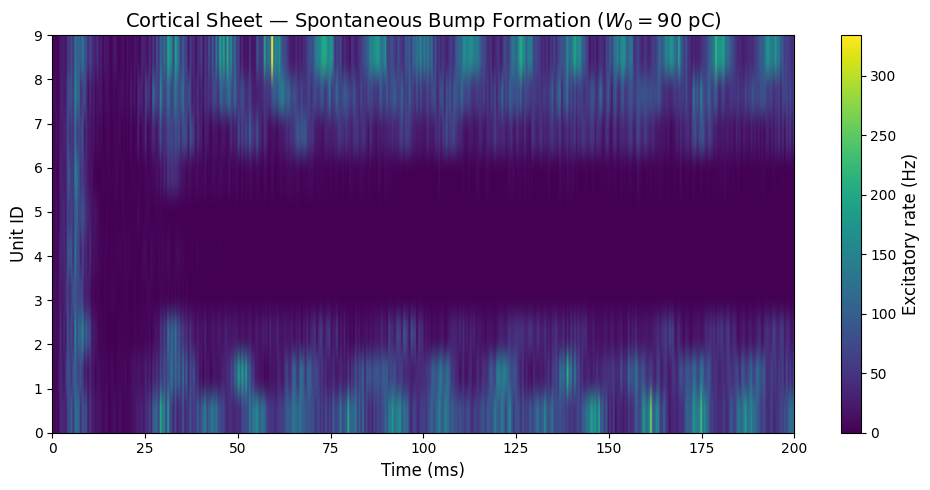

In [9]:
# ── Exercise 2.4 ─────────────────────────────────────────────────────────────

Nunits   = 10
sigma_c  = 0.2
T_24     = 200.0
n24      = int(T_24 / dt)

def simulate_cortical_sheet(W0, T=200.0, seed=3):
    """Simulate the ring of E-I units and return excitatory activity (Nunits x n_steps)."""
    np.random.seed(seed)
    W_EE, W_IE = generate_unit_connectivity(Nunits, sigma_c, W0, g_val, gamma)
    units  = [EIUnit(generate_sparse_connectivity(NE, NI, KE, KI, J_val, g_val))
              for _ in range(Nunits)]
    n_steps = int(T / dt)
    actE    = np.zeros((Nunits, n_steps))
    actI    = np.zeros((Nunits, n_steps))

    for step in range(n_steps):
        rE_past = actE[:, step - delay_steps] if step >= delay_steps else np.zeros(Nunits)

        for alpha in range(Nunits):
            # Unit-unit inputs (rate in Hz → divide by 1000 to get spike/ms)
            I_E_field = np.dot(W_EE[alpha, :], rE_past) / 1000.0
            I_I_field = np.dot(W_IE[alpha, :], rE_past) / 1000.0
            rE, rI    = units[alpha].step(I_E_field, I_I_field)
            actE[alpha, step] = rE
            actI[alpha, step] = rI

    return actE, actI

actE_24, _ = simulate_cortical_sheet(W0=90.0)

time_24 = np.arange(n24) * dt
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(actE_24, aspect='auto', origin='lower',
               extent=[0, T_24, 0, Nunits-1], cmap='viridis')
plt.colorbar(im, ax=ax, label='Excitatory rate (Hz)')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Unit ID')
ax.set_title('Cortical Sheet — Spontaneous Bump Formation ($W_0=90$ pC)')
plt.tight_layout()
plt.show()


**Discussion (2.4):**

- **Bump stability:** The bump is self-sustaining because of the Mexican-hat interactions:
  units *within* distance $\sigma$ of the bump centre excite each other via $W_{EE}$,
  while units *beyond* $\sigma$ are inhibited via the long-range $W_{IE}$ projection.
  This produces a stable "winning" cluster.
- **Emergence time:** The bump typically forms within the first 50–100 ms, triggered by
  background noise breaking the translational symmetry. The winning location varies
  between runs (attractor continuum).


**2.5.** Repeat for varying $W_0$. Report the minimum value of $W_0$ needed to produce a bump.


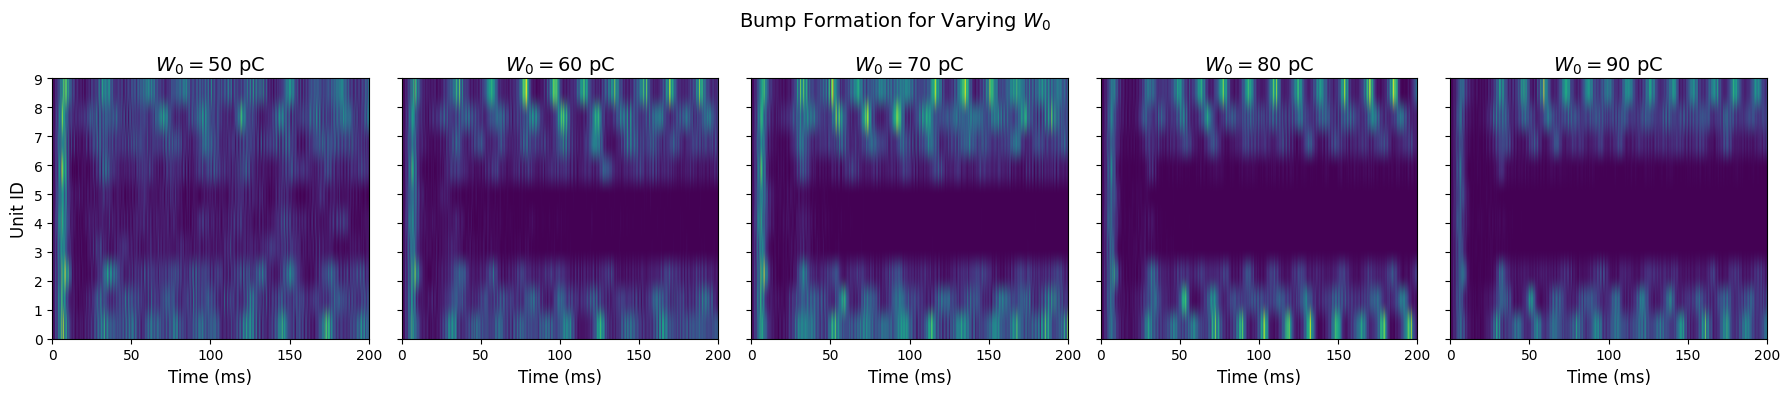

In [10]:
# ── Exercise 2.5 ─────────────────────────────────────────────────────────────

W0_scan = [50, 60, 70, 80, 90]
fig, axes = plt.subplots(1, len(W0_scan), figsize=(18, 4), sharey=True)

for ax, W0 in zip(axes, W0_scan):
    actE, _ = simulate_cortical_sheet(W0=W0)
    ax.imshow(actE, aspect='auto', origin='lower',
              extent=[0, T_24, 0, Nunits-1], cmap='viridis')
    ax.set_title(f'$W_0={W0}$ pC')
    ax.set_xlabel('Time (ms)')

axes[0].set_ylabel('Unit ID')
plt.suptitle('Bump Formation for Varying $W_0$', fontsize=14)
plt.tight_layout()
plt.show()


**Observation (2.5):** A stable, persistent bump typically emerges for $W_0 \gtrsim 80$ pC.
Below this value the inter-unit excitation is too weak to overcome the background noise and
sustain a localised cluster.


---
## Exercise 3 — Paradoxical Response Properties

We now probe the cortex sheet model with localised external stimuli to reproduce **surround
suppression** — the decrease in firing rate observed when the stimulus size grows beyond
the excitatory range $\sigma$.

---

**3.1.** Simulate the network for $T=200$ ms with $W_0=45$ pC (below the critical value
found in Ex. 2.5). Apply a step input of strength $I_0=30$ nA to the E population of unit 5
starting at $t=100$ ms. Produce an activity heatmap. Describe what you observe.


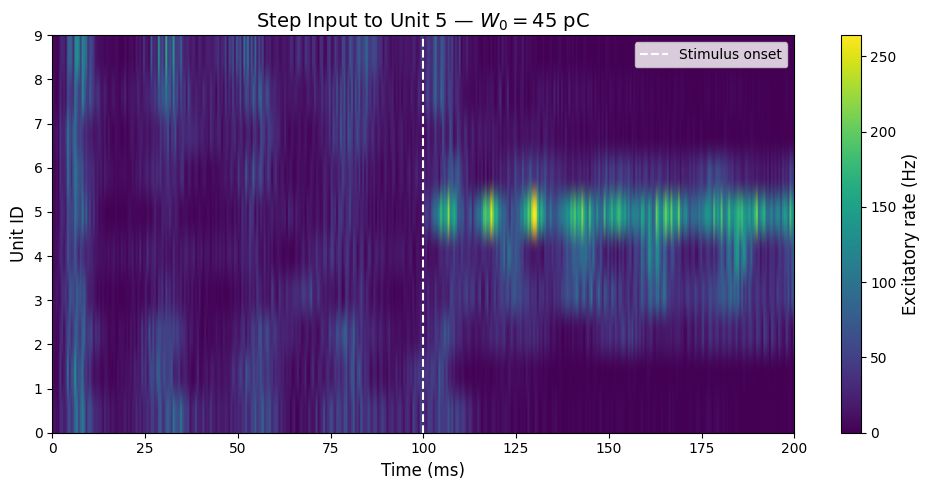

In [11]:
# ── Exercise 3.1 ─────────────────────────────────────────────────────────────

W0_31    = 45.0
np.random.seed(5)
W_EE_31, W_IE_31 = generate_unit_connectivity(Nunits, sigma_c, W0_31, g_val, gamma)
units_31 = [EIUnit(generate_sparse_connectivity(NE, NI, KE, KI, J_val, g_val))
            for _ in range(Nunits)]

n31   = int(T_24 / dt)
actE_31 = np.zeros((Nunits, n31))

for step in range(n31):
    rE_past = actE_31[:, step - delay_steps] if step >= delay_steps else np.zeros(Nunits)
    for alpha in range(Nunits):
        I_E_field = np.dot(W_EE_31[alpha, :], rE_past) / 1000.0
        I_I_field = np.dot(W_IE_31[alpha, :], rE_past) / 1000.0
        # Step stimulus to unit 5 from t=100 ms
        if alpha == 5 and step * dt >= 100.0:
            I_E_field += 30.0        # nA
        rE, rI = units_31[alpha].step(I_E_field, I_I_field)
        actE_31[alpha, step] = rE

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(actE_31, aspect='auto', origin='lower',
               extent=[0, T_24, 0, Nunits-1], cmap='viridis')
plt.colorbar(im, ax=ax, label='Excitatory rate (Hz)')
ax.axvline(100, color='white', lw=1.5, linestyle='--', label='Stimulus onset')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Unit ID')
ax.set_title('Step Input to Unit 5 — $W_0=45$ pC')
ax.legend()
plt.tight_layout()
plt.show()


**Observations (3.1):**

- Unit 5 sharply increases its activity after stimulus onset ($t=100$ ms).
- Distant units (e.g. 0, 1, 9) are **suppressed** below their spontaneous rate via long-range
  $W_{IE}$ connections — the stimulated E unit drives the I populations of far-away units.
- $W_0 < 80$ pC is critical: if $W_0$ were above the critical value, a spontaneous bump would
  already be present and would mask the stimulus-driven response.

**3.2.** Plot the mean excitatory activity (**after stimulus onset**) across unit locations.
Argue why this is equivalent to the **tuning curve** of a single unit as a function of stimulus
location.


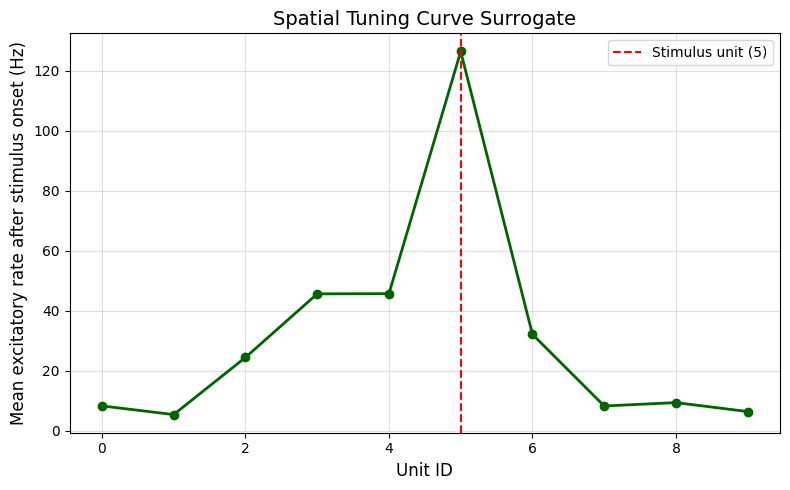

In [12]:
# ── Exercise 3.2 ─────────────────────────────────────────────────────────────

mean_post_stim = np.mean(actE_31[:, int(100.0 / dt):], axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(Nunits), mean_post_stim, 'o-', color='darkgreen', lw=2)
ax.axvline(5, color='red', linestyle='--', lw=1.5, label='Stimulus unit (5)')
ax.set_xlabel('Unit ID')
ax.set_ylabel('Mean excitatory rate after stimulus onset (Hz)')
ax.set_title('Spatial Tuning Curve Surrogate')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


**Argument (3.2):** Due to the **translational symmetry** of the ring, the response of unit
$\alpha$ to a stimulus at unit 5 is identical to the response of unit 5 to a stimulus placed
$|\alpha-5|$ positions away. Therefore, this plot — activity as a function of unit *location*
relative to the stimulus — maps one-to-one onto the tuning curve of unit 5 as a function of
stimulus *location*.


**3.3.** Plot the mean excitatory firing rate of unit 5 as a function of **stimulus width**
$\sigma_{stim}\in[0, 0.4]$ (step 0.04), with Gaussian input centred at unit 5:

$$I^{ext,E}_\alpha(t) = I_0\exp\!\left(-\frac{d(x_\alpha,x_0)^2}{2\sigma_{stim}^2}\right), \quad I_0=30\text{ nA}$$


Varying stimulus width:   0%|          | 0/11 [00:00<?, ?it/s]

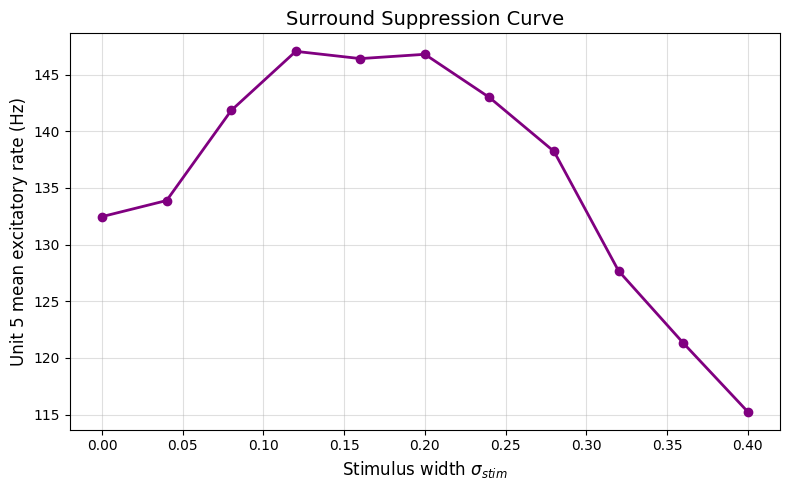

In [13]:
# ── Exercise 3.3 ─────────────────────────────────────────────────────────────

sigma_stims = np.arange(0.0, 0.44, 0.04)
positions   = np.linspace(0, 1, Nunits, endpoint=False)
x0          = positions[5]
target_rates = []

for s_stim in tqdm(sigma_stims, desc="Varying stimulus width"):
    np.random.seed(5)
    units_33 = [EIUnit(generate_sparse_connectivity(NE, NI, KE, KI, J_val, g_val))
                for _ in range(Nunits)]
    actE_33  = np.zeros((Nunits, n31))

    # Pre-compute Gaussian input profile
    I_base = np.zeros(Nunits)
    if s_stim == 0.0:
        I_base[5] = 30.0
    else:
        for a in range(Nunits):
            d_a  = abs(positions[a] - x0)
            dist = min(d_a, 1.0 - d_a)
            I_base[a] = 30.0 * np.exp(-(dist**2) / (2 * s_stim**2))

    for step in range(n31):
        rE_past = actE_33[:, step - delay_steps] if step >= delay_steps else np.zeros(Nunits)
        for alpha in range(Nunits):
            I_E_field = np.dot(W_EE_31[alpha, :], rE_past) / 1000.0 + I_base[alpha]
            I_I_field = np.dot(W_IE_31[alpha, :], rE_past) / 1000.0
            rE, _     = units_33[alpha].step(I_E_field, I_I_field)
            actE_33[alpha, step] = rE

    # Mean over last 150 ms (step 100 ms onward)
    target_rates.append(np.mean(actE_33[5, int(50.0 / dt):]))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sigma_stims, target_rates, 'o-', color='purple', lw=2)
ax.set_xlabel('Stimulus width $\sigma_{stim}$')
ax.set_ylabel('Unit 5 mean excitatory rate (Hz)')
ax.set_title('Surround Suppression Curve')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


**3.4. Why does the rate decrease for wide stimuli?**

At small $\sigma_{stim}$, only unit 5 and its close neighbours receive substantial input.
Their excitatory activity is amplified by short-range $W_{EE}$ connections.

When $\sigma_{stim}$ exceeds the excitatory range $\sigma_c = 0.2$, distant units start
receiving significant input. These distant E units project strongly via $W_{IE}$ onto the
inhibitory population of unit 5, increasing I-population activity and suppressing unit 5.
The inhibitory drive eventually outweighs the direct excitatory input, causing the **surround
suppression** dip observed in the curve.

**3.5. What is the direct cause?**

In our model, the direct cause is **increased inhibition** of the E population of unit 5.
As $\sigma_{stim}$ grows, the I population of unit 5 receives progressively more excitatory
drive from peripheral units (through $W_{IE}$), raising I activity and increasing the
inhibitory current delivered to unit 5's E neurons. This is consistent with the
**inhibition-dominated** regime (Ex. 1.4): in an ISN, stimulating E neurons in the surround
paradoxically increases local inhibition rather than excitation. If an experimenter could only
measure the *direct* cause (increased I activity in unit 5) without knowing the circuit, they
would correctly infer an ISN signature — inhibition that is stabilised and driven by the
very excitation it suppresses.


---
## Exercise 4 — Final Question

**[Biology-oriented]**

Visual surround suppression is a well-documented phenomenon in primary visual cortex (V1):
the firing rate of a neuron in response to an optimally oriented grating *decreases* when
the grating is extended into the neuron's surround (Ozeki et al., 2009).

**Proposed experiment to test the model predictions:**

1. **Preparation:** Use in-vivo two-photon calcium imaging in awake, head-fixed mice viewing
   full-screen gratings on a monitor. Target layer 2/3 of V1 and simultaneously image
   excitatory (Thy1-GCaMP6f) and PV-positive inhibitory (PV-Cre × Ai148) neurons using
   spectrally distinct indicators.

2. **Stimulus protocol:** Present drifting sinusoidal gratings at the optimal orientation of a
   target excitatory neuron, systematically varying the stimulus diameter from $0.5°$ to $30°$
   in steps of $2°$ (analogous to increasing $\sigma_{stim}$ in our model).

3. **Critical manipulation:** Selectively silence PV interneurones in a small patch surrounding
   the target cell (matching the long-range $W_{IE}$ range) using soma-targeted halorhodopsin
   activated by a widefield red LED during the large-stimulus trials only.

4. **Prediction from the model (Ex. 3.5):** Silencing the local I population should
   *rescue* the suppression — the target cell should maintain its peak firing rate even for
   large stimuli, because the circuit mechanism (ISN surround inhibition mediated by $W_{IE}$)
   has been disrupted. If instead suppression persists, a purely feedforward (non-ISN)
   mechanism would be implicated.

5. **Additional module needed:** To compare quantitatively, the model would need a
   Gaussian spatial stimulus kernel projected onto the ring (already implemented in Ex. 3.3)
   plus a readout that mimics the calcium indicator's temporal dynamics (single-exponential
   convolution with $\tau_{GCaMP}\approx 400$ ms). This would allow direct comparison
   between simulated firing rates and experimentally measured $\Delta F/F$ traces.
